In [24]:
# Copyright 2026 - Osmar Yupanqui & Marvin Quispe
# Conservación Amazónica - ACCA
#
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
#     https://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

# Selective Logging Detection with Deep Learning and Very-High Resolution Imagery

#### Authors: Osmar Yupanqui and Marvin Quispe

<br>

## Part 3: Model Application

### This notebook demonstrates the workflow used to apply our deep learning model locally, which was trained and saved in the previous notebook (Notebook n.º2). We will load the trained U-Net model, as well as our SkySat image. We will split the image into patches and apply the model to each patch separately. Finally, we will merge all the fragments and resynthesize the image. This workflow is designed for use in Google Colab.

## 1. Imports

This notebook will require the following packages:
- TensorFlow
- Numpy
- GDAL
- Google Drive
- Matplotlib

We will again import the [TensorFlow](https://www.tensorflow.org/) library, to load our model and apply it.

In [1]:
import tensorflow as tf
print(tf.__version__)

2.19.0


Also [Numpy](https://numpy.org/) for manipulating the tensors (patches). Note that TensorFlow has many built-in functions that have the same capabilities as Numpy. However, this notebook will use Numpy.

In [2]:
import numpy as np

[GDAL](https://gdal.org/en/stable/) is also a fundamental library, that allows us to save, export and manipulate rasters. It is also used in [QGIS](https://www.qgis.org/) in many tools. Note that there are other libraries that can read satellite images such as [Rasterio](https://rasterio.readthedocs.io/) and [Rioxarray](https://corteva.github.io/rioxarray/). However, GDAL is a core library that is used as a backend by these more modern packages.

In [3]:
from osgeo import gdal

Again, we will link our notebook with Google Drive. Note that there are different platforms to store models, such as [Hugging Face](https://huggingface.co/). However, we will work with Google Drive for its practicality.

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


And finally import [Matplotlib](https://matplotlib.org/) for the visualization.

In [5]:
import matplotlib.pyplot as plt

If you do not wish to run the previous notebooks, you can create a copy from the original folder. Click [here](https://drive.google.com/drive/folders/1v30R0-2j5WkgekRxYUw4PHS04c2N9YJR) to go to the Drive folder. Make sure to modify the paths to match the current Notebook.

## 2. Model loading

If you have followed the previous steps, you will have your model stored already in Google Drive, we will load our model with the `tf.keras.models.load_model()` function.

In [6]:
modelDir = '/content/drive/MyDrive/DL_Book/model/logging_model.keras'
model = tf.keras.models.load_model(modelDir)

We can visualize the structure of our loaded model and the amount of parameters in each layer.

In [7]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 4)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │      1,184 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128, 128,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │      9,248 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │     36,928 │ activation_2[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ activation_3[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        512 │ conv2d_4[0][0]  

 Total params: 93,348,357 (356.10 MB)

 Trainable params: 31,110,785 (118.68 MB)

 Non-trainable params: 16,000 (62.50 KB)

 Optimizer params: 62,221,572 (237.36 MB)

Next, we will download a very-high resolution image from SkySat (0.5 m), we will use the `wget` linux command.

In [8]:
!wget --no-check-certificate 'https://docs.google.com/uc?export=download&id=1ZuBn22ZS-pkCU5ii-x2FraWpn6Y8oevO' -O Skysat_20201017_ssc2_150055_COG_clip.tif

--2026-03-24 20:32:13--  https://docs.google.com/uc?export=download&id=1ZuBn22ZS-pkCU5ii-x2FraWpn6Y8oevO
Resolving docs.google.com (docs.google.com)... 108.177.96.102, 108.177.96.138, 108.177.96.101, ...
Connecting to docs.google.com (docs.google.com)|108.177.96.102|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1ZuBn22ZS-pkCU5ii-x2FraWpn6Y8oevO&export=download [following]
--2026-03-24 20:32:13--  https://drive.usercontent.google.com/download?id=1ZuBn22ZS-pkCU5ii-x2FraWpn6Y8oevO&export=download
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 142.250.153.132, 2a00:1450:4013:c16::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|142.250.153.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 9502759 (9.1M) [application/octet-stream]
Saving to: ‘Skysat_20201017_ssc2_150055_COG_clip.tif’

Skysat_20201017_ssc 100%[================

Let's visualize the downloaded image!

/usr/local/lib/python3.12/dist-packages/osgeo/gdal.py:312: FutureWarning: Neither gdal.UseExceptions() nor gdal.DontUseExceptions() has been explicitly called. In GDAL 4.0, exceptions will be enabled by default.
  warnings.warn(


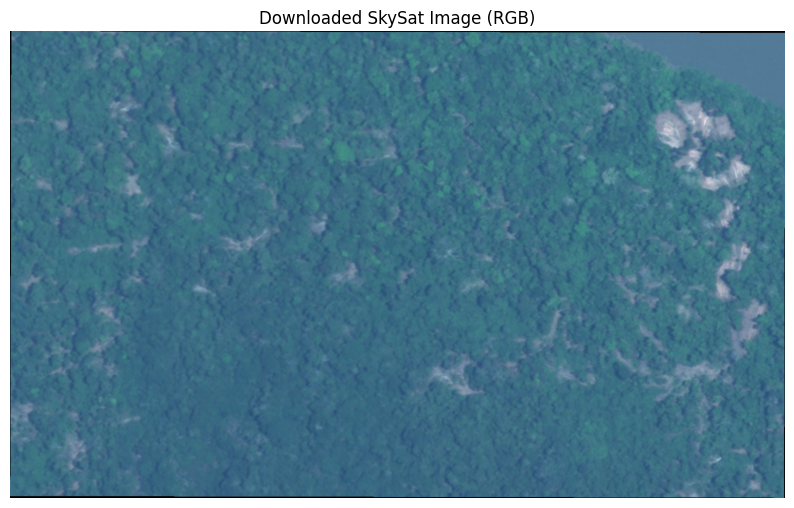

In [9]:
img_path = 'Skysat_20201017_ssc2_150055_COG_clip.tif'
img_to_viz = gdal.Open(img_path, gdal.GA_ReadOnly)

img_array_viz = img_to_viz.ReadAsArray().transpose([1, 2, 0])
rgb_img = np.divide(np.stack([img_array_viz[:,:,2], img_array_viz[:,:,1], img_array_viz[:,:,0]]), 12000.0)

plt.figure(figsize=(10, 10))
plt.imshow(rgb_img.transpose(1, 2, 0))
plt.title('Downloaded SkySat Image (RGB)')
plt.axis('off')
plt.show()

del img_to_viz


This satellite image was taken from an indigenous community called [Fatima](https://www.maapprogram.org/es/tala-fatima/) in the year 2021. In this community, more than 300 trees were detected being cut down. Imagine how long it would take a GIS specialist to gather data through manual digitization. We will apply the already trained model to the image and analyze the output of the model.

## 3. Model application

We will define the input path of our image, and the desired output path.

In [10]:
img_path = 'Skysat_20201017_ssc2_150055_COG_clip.tif'
out_path = 'Skysat_20201017_ssc2_150055_COG_pred.tif'

With `gdal.Open()` we can get important details about our image and use the [GDAL python API](https://gdal.org/en/latest/api/python/index.html).

In [11]:
img = gdal.Open(img_path, gdal.GA_ReadOnly)

We are interested in the pixel values, so we will read the image as an array. Since GDAL returns the image with the structure **(Bands, Height, Width)**, we will transpose our image to the following structure **(Height, Width, Bands)**

In [12]:
img_array = img.ReadAsArray().transpose([1, 2, 0])
print(img_array.shape)

(997, 1656, 4)


Since our model is object-based, it operates according to patches, and our image must match its input size (in this case 128 by 128). We will add a zero padding to the borders of our image, to have compatible patch sizes. The following code calculates the amount of rows and columns to add with the 0 padding.

In [13]:
print('rows (heigth) to add with 0: ', 128 - img_array.shape[0] % 128)
print('cols (width) to add with 0: ', 128 - img_array.shape[1] % 128)

rows (heigth) to add with 0:  27
cols (width) to add with 0:  8


This block of code will create a zero row padding, and append it to the original image

In [14]:
row_padding = np.zeros([128 - img_array.shape[0] % 128, img_array.shape[1], img_array.shape[2]])
img_rdy = np.append(img_array, row_padding, axis = 0)
img_rdy.shape

(1024, 1656, 4)

This will add a zero column padding. Notice that the final size of the image is entirely divisible by the patch size (128)

In [15]:
col_padding = np.zeros([img_rdy.shape[0], 128 - img_array.shape[1] % 128, img_array.shape[2]])
img_rdy = np.append(img_rdy, col_padding, axis = 1)
img_rdy.shape

(1024, 1664, 4)

We will use some functions of the [Patchify](https://github.com/dovahcrow/patchify.py) library. To extract patches of equal size from our input image, this function uses Numpy.

In [16]:
# Patchification
def patchification(arr_in, window_shape, step = 1):

    # Dimensions of the input array
    ndim = arr_in.ndim

    # Step multiplied the amount of dimensions
    step = (step,) * ndim

    # Create a sliding window
    slices = tuple(slice(None, None, st) for st in step)

    # Obtain the strides of the input array
    window_strides = np.array(arr_in.strides)

    # Obtain the strides of the moving window applied to the input array
    indexing_strides = arr_in[slices].strides

    # Generate a shape with the amount of patches per row and column
    win_indices_shape = (
        (np.array(arr_in.shape) - np.array(window_shape)) // np.array(step)
    ) + 1

    # Generate the final shape of the output
    new_shape = tuple(list(win_indices_shape) + list(window_shape))

    # Merge the strides of the index and window
    strides = tuple(list(indexing_strides) + list(window_strides))

    # Obtain the patches
    arr_out = np.lib.stride_tricks.as_strided(arr_in, shape = new_shape, strides = strides)
    return arr_out

This block of code uses the previously created function to extract our patches. Notice that by using `.reshape()` we are concatenating each patch and now we have an extra dimesion. Our structure now is (Batch, Height, Width, Band). In this case, the batch is the number of patches on which the model will be applied.

In [17]:
patches = patchification(img_rdy, [128, 128, 4], 128) \
    .reshape([int((img_rdy.shape[0] * img_rdy.shape[1]) / (128 * 128)), 128, 128, 4])
patches.shape

(104, 128, 128, 4)

Finally, we apply our model to our structured patches.

In [18]:
# Apply the model on the processed array
predictions = model.predict(patches, verbose = 1)

4/4 ━━━━━━━━━━━━━━━━━━━━ 27s 6s/step


We will create another function, that unpatchifies our predictions.

In [19]:
# Function to merge the patches
def unpatchification(arr_in, window_shape, height, width):
    result_array = np.empty([img_rdy.shape[0], img_rdy.shape[1], 1])
    row = 0
    col = 0
    for patch in arr_in:
        result_array[window_shape[0] * row : window_shape[0] * (row + 1), window_shape[1] * col : window_shape[1] * (col + 1), :] = patch
        col += 1

        if (window_shape[1] * col) == width:
            row += 1
            col = 0
    return result_array

Notice the `.transpose()` function, that will restore the original shape used by GDAL (Band, Width, Height)

In [20]:
# The predictions must be reshaped to the same dimensions of the input image
final = unpatchification(predictions, [128, 128], img_rdy.shape[0], img_rdy.shape[1]).transpose([2, 0, 1])
final = final[:, 0 : img_array.shape[0], 0 : img_array.shape[1]]
final.shape

(1, 997, 1656)

Finally, we will load our predictions, and register its metadata to GDAL. The most important aspect in this step is the **projection**. It must match the input image. Otherwise, our image won't have a location in the space.

In [21]:
# Now we will register a new image using GDAL
driver = gdal.GetDriverByName('GTiff')
driver.Register()

# We'll use the shapes of the output
outDataset = driver.Create(out_path, final.shape[2], final.shape[1], final.shape[0], gdal.GDT_Float32)
outDataset.SetProjection(img.GetProjection())
outDataset.SetGeoTransform(img.GetGeoTransform())
outDataset.GetRasterBand(1).WriteArray(final[0, :, :], 0, 0)

del outDataset

We can visualize our predictions and the input image.

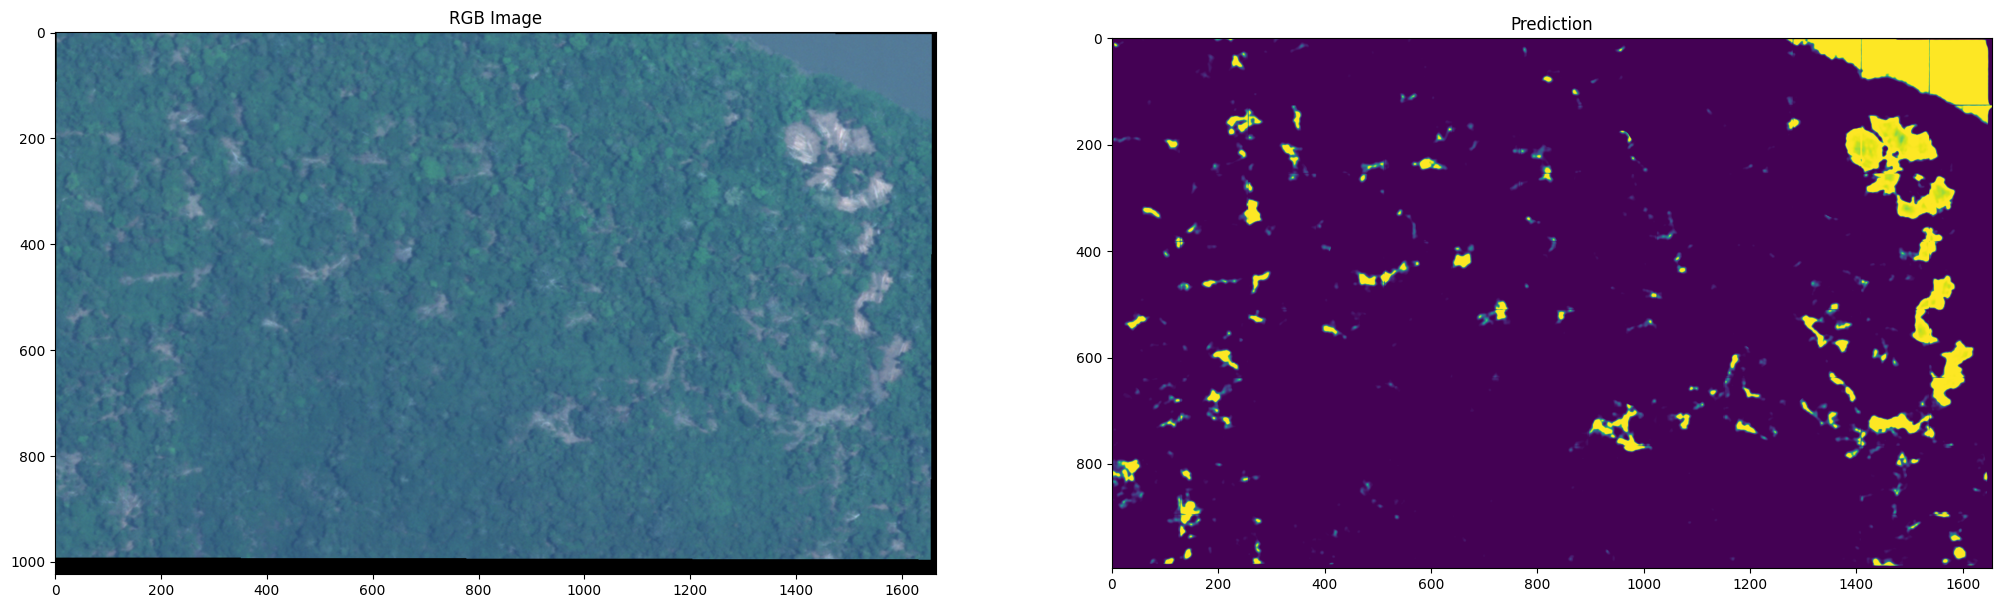

In [22]:
fig, axs = plt.subplots(1, 2, figsize = (25, 25))

axs[0].set_title('RGB Image')
axs[0].imshow(np.transpose(np.divide(np.stack([img_rdy[:,:,2], img_rdy[:,:,1], img_rdy[:,:,0]]), 12000), [1, 2, 0]))

axs[1].set_title('Prediction')
axs[1].imshow(final[0, :, :])

plt.show()

As you can see, models are not perfect. There are some artifacts that affect our predictions. There are subtle vertical and horizontal lines creating a grid pattern across the entire prediction. This is because the model sees each patch independently without context of adjacent areas. There are also features that span tile boundaries and get processed differently on each side. There are advanced techniques to solve this, such as creating an overlap-tile strategy. This means processing patches with 50% overlap and blend the output. Another way to solve this would be through weighted averaging, which is giving more weight to center of patches, and less to edges.

## 4. Discussion

We have successfully applied our model to a scene from a SkySat image. Through visual inspection, we can see that the model isn't perfect. In fact, it confuses water with selective logging. This is possibly due to the limited amount of data containing water as a background. Another interesting effect is the edge effect. You can see in the upper right corner of the predictions that there are lines with low probability. This can be corrected by overlapping patches.

To evaluate the effectiveness of the model, validation is necessary. There are different validation techniques, with numerous types of sampling. However, this notebook will not address these topics as they are subjective, in line with the study objective.

We encourage you to make changes to these notebooks, configure hyperparameters, patch size, batch size, learning rate, epochs, among others.

## 5. Optional - cleaning your folder

Use the following code to clean the contents of your folder.

In [ ]:
#!rm -rf /content/drive/MyDrive/DL_Book/*

You can also do it manually in Google Drive.